In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/closest_contacts_1mm.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/closest_contacts_1mm.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/closest_contacts_1mm.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/closest_contacts_1mm.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/closest_contacts_1mm.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': '#fc8c59',
    '23129': '#fee2bb',
    '33300': '#fdc38d',
}


      comparison    U        p significance
anosmic vs wiii8  2.0 0.000328          ***
   9047 vs wiii8 41.0 0.520523           ns
  23129 vs wiii8 15.0 0.009108           **
  33300 vs wiii8 11.0 0.003611           **


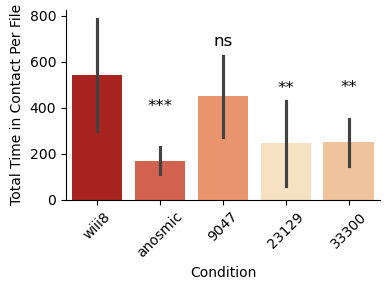

In [5]:
from scipy.stats import mannwhitneyu

contacts_per_file = (
    df.groupby(['condition', 'file'])['frame']
    .apply(lambda x: x.notna().sum())
    .reset_index(name='total_contacts')
)

control = contacts_per_file.loc[contacts_per_file['condition'] == 'wiii8', 'total_contacts']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = contacts_per_file.loc[contacts_per_file['condition'] == condition, 'total_contacts']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))


plt.figure(figsize=(4,3))

ax = sns.barplot(
    data=contacts_per_file,
    x='condition',
    y='total_contacts',
    hue='condition',
    hue_order=condition_order,
    errorbar='sd',
    palette=condition_colors,
    order=condition_order,
    legend=False,
)

y_offset = contacts_per_file['total_contacts'].max() * 0.2
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = contacts_per_file.loc[contacts_per_file['condition'] == condition, 'total_contacts'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.xticks(rotation=45)
plt.ylim(0, None)
plt.ylabel('Total Time in Contact Per File')
plt.xlabel('Condition')
sns.despine()

plt.tight_layout()
plt.show()

contact_type       comparison    U        p significance
   head_head anosmic vs wiii8  7.0 0.001309           **
   head_head    9047 vs wiii8 42.5 0.596563           ns
   head_head   23129 vs wiii8 20.0 0.025748            *
   head_head   33300 vs wiii8  9.0 0.002202           **
   body_head anosmic vs wiii8  3.0 0.000437          ***
   body_head    9047 vs wiii8 33.5 0.226301           ns
   body_head   23129 vs wiii8 10.0 0.002827           **
   body_head   33300 vs wiii8  7.0 0.001309           **
   head_tail anosmic vs wiii8  1.0 0.000246          ***
   head_tail    9047 vs wiii8 36.0 0.307489           ns
   head_tail   23129 vs wiii8 12.0 0.004586           **
   head_tail   33300 vs wiii8 17.5 0.015526            *
   body_tail anosmic vs wiii8  9.0 0.002160           **
   body_tail    9047 vs wiii8 46.5 0.820463           ns
   body_tail   23129 vs wiii8 23.5 0.049281            *
   body_tail   33300 vs wiii8 26.0 0.075442           ns
   tail_tail anosmic vs wiii8 2

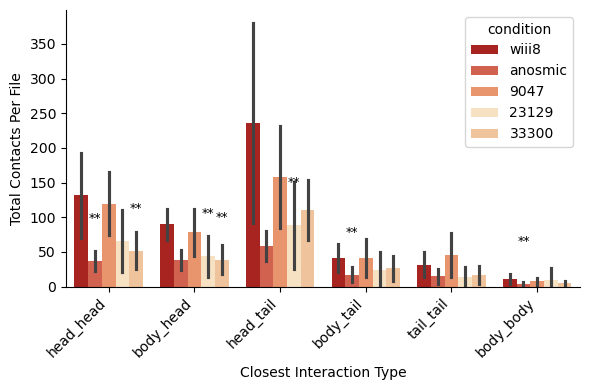

In [6]:
from scipy.stats import mannwhitneyu

contacts_per_file_type = (
    df.groupby(['condition', 'file', 'Closest Interaction Type'])
    .size()
    .reset_index(name='total_contacts')
)

files = df[['condition', 'file']].drop_duplicates()
contact_types = df[['Closest Interaction Type']].drop_duplicates()
contacts_per_file_type = (
    files.merge(contact_types, how='cross')
    .merge(contacts_per_file_type, on=['condition', 'file', 'Closest Interaction Type'], how='left')
)
contacts_per_file_type['total_contacts'] = contacts_per_file_type['total_contacts'].fillna(0)
contact_type_order = contact_types['Closest Interaction Type'].tolist()

stats_rows = []

for contact_type in contact_type_order:
    control = contacts_per_file_type.loc[
        (contacts_per_file_type['condition'] == 'wiii8') &
        (contacts_per_file_type['Closest Interaction Type'] == contact_type),
        'total_contacts'
    ]

    for condition in condition_order:
        if condition == 'wiii8':
            continue

        test_group = contacts_per_file_type.loc[
            (contacts_per_file_type['condition'] == condition) &
            (contacts_per_file_type['Closest Interaction Type'] == contact_type),
            'total_contacts'
        ]

        u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'ns'

        stats_rows.append({
            'contact_type': contact_type,
            'comparison': f'{condition} vs wiii8',
            'U': u_stat,
            'p': p_value,
            'significance': significance,
        })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=contacts_per_file_type,
    x='Closest Interaction Type',
    y='total_contacts',
    order=contact_type_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
)

y_offset = contacts_per_file_type['total_contacts'].max() * 0.1
for bars, condition in zip(ax.containers, condition_order):
    if condition == 'wiii8':
        continue

    for bar, contact_type in zip(bars, contact_type_order):
        row = stats_table.loc[
            (stats_table['contact_type'] == contact_type) &
            (stats_table['comparison'] == f'{condition} vs wiii8')
        ]

        if len(row) > 0 and row['significance'].iloc[0] == '**':
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_height() + y_offset
            ax.text(x, y, '**', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Contacts Per File')
plt.xlabel('Closest Interaction Type')
plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.show()